<a href="https://colab.research.google.com/github/mendozalz/DataScience--US-Superstore-Sales-Analysis-/blob/main/Curso_Data_Science_(US-Superstore-Sales-Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [4]:
data = pd.read_excel('/content/sample_data/US Superstore data.xls')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [6]:
data.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


# Preguntas para nuestro análisis

1. ¿Cuál es el volumen total de ventas y la ganancia total?
2. ¿Qué productos generan más ingresos y cuáles más pérdidas?
3. ¿Cuáles son los márgenes de ganancia promedio por categoría y subcategoría?
4. ¿Qué impacto tienen los descuentos en las ganancias?
5. ¿Qué segmento de clientes genera más ingresos y cuál más ganancias?
6. ¿Quiénes son los clientes más valiosos (mayor gasto total)?
7. ¿Cuántos clientes únicos hay por región o segmento?
8. Tiempo promedio entre pedido y envío
9. Método de envío más usado y más rentable
10. Total de ventas por mes


# 1 ¿Cuál es el volumen total de ventas y la ganancia total?


In [7]:
# ¿Cuál es el volumen total de ventas y la ganancia total?

venta_total = data['Sales'].sum()
ganacia_total = data['Profit'].sum()

print(f"Venta total es de. {venta_total:.2f}")
print(f"Ganancia total es de: {ganacia_total:.2f}")

Venta total es de. 2297200.86
Ganancia total es de: 286397.02


# 2 ¿Qué productos generan más ingresos y cuáles más pérdidas?

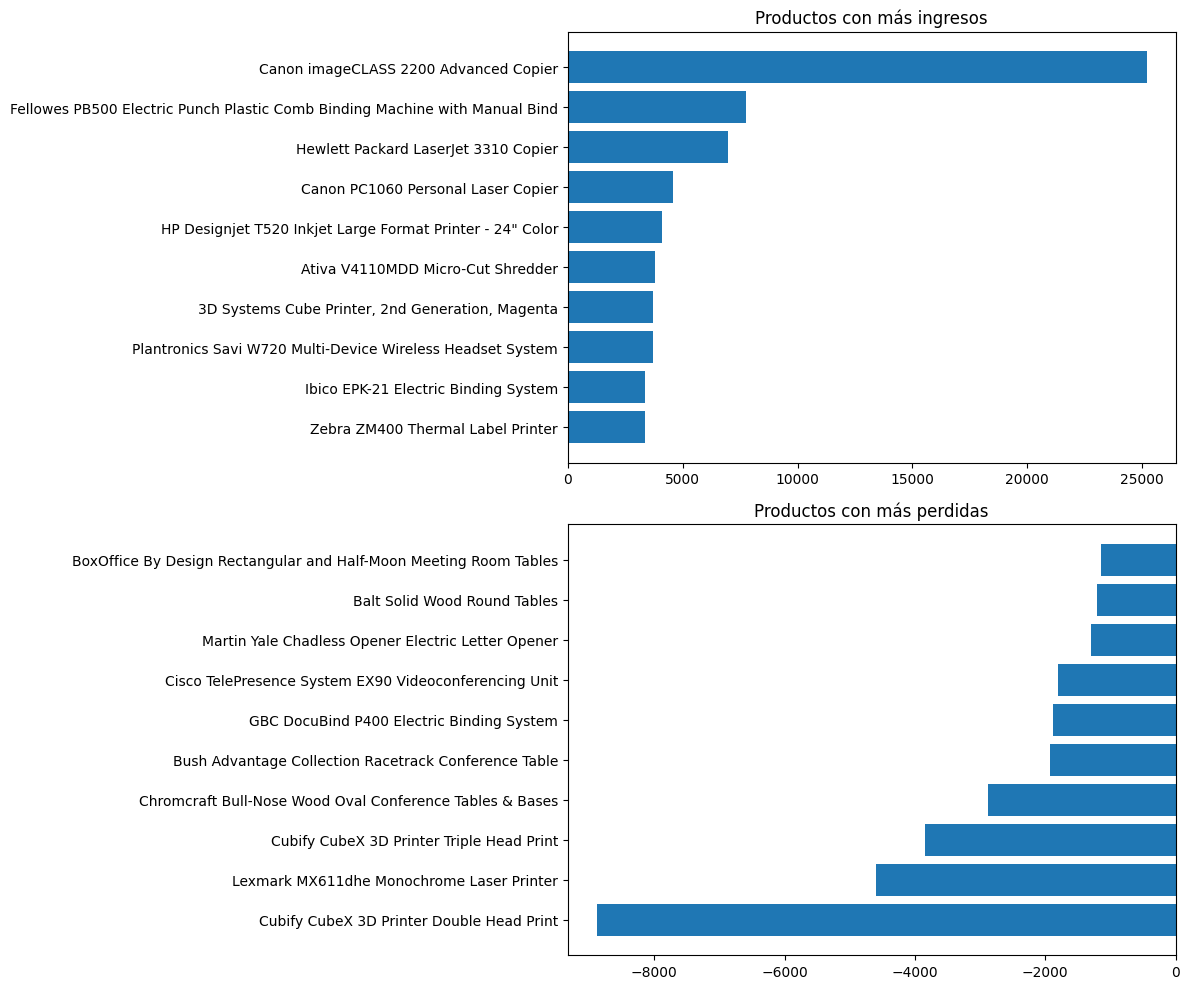

In [8]:
# ¿Qué productos generan más ingresos y cuáles más pérdidas?
product_ganacias = data.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)
ganancias = product_ganacias.head(10)
perdidas = product_ganacias.tail(10)

fig, ax = plt.subplots(2, 1, figsize=(12,10))

primeraGrafica = ax[0]
segundaGrafica = ax[1]

primeraGrafica.barh(ganancias.index, ganancias.values)
primeraGrafica.set_title('Productos con más ingresos')
primeraGrafica.invert_yaxis()

segundaGrafica.barh(perdidas.index, perdidas.values)
segundaGrafica.set_title('Productos con más perdidas')
segundaGrafica.invert_yaxis()

plt.tight_layout()
plt.show()

# 3. ¿Cuáles son los márgenes de ganancia promedio por categoría y subcategoría?

In [9]:
# ¿Cuáles son los márgenes de ganancia promedio por categoría y subcategoría?
data['Margen'] = data['Profit'] / data['Sales']

categoria_margen = data.groupby('Category')['Margen'].mean()*100
categoria_margen

,Margen
Category,
Furniture,3.878353
Office Supplies,13.803029
Technology,15.613805


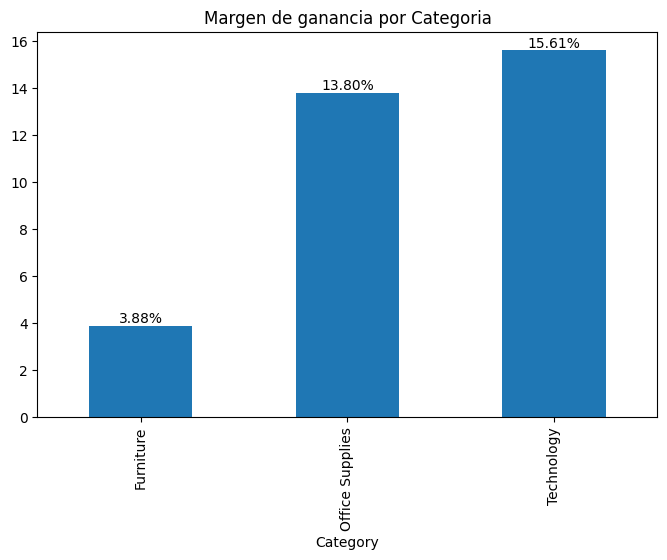

In [10]:
plt.figure(figsize=(8,5))
categoria_margen.plot(kind='bar')
plt.title('Margen de ganancia por Categoria')
for i, v in enumerate(categoria_margen):
  plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')
plt.show()

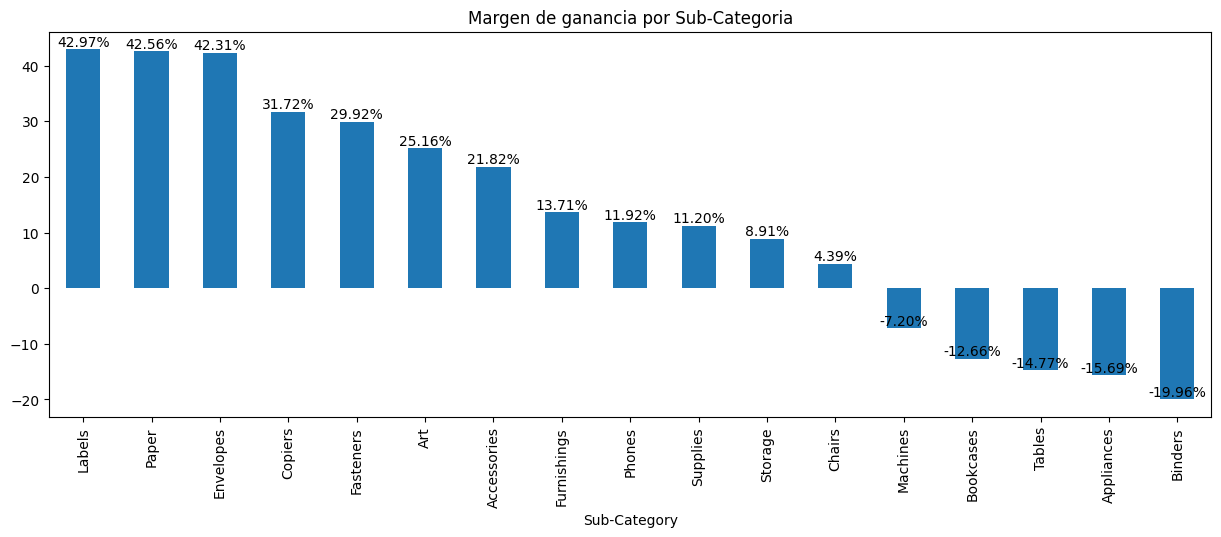

In [11]:
# Sub-Categoria

sub_cat = data.groupby('Sub-Category')['Margen'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(15,5))
sub_cat.plot(kind='bar')
plt.title('Margen de ganancia por Sub-Categoria')
for i, v in enumerate(sub_cat):
  plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')
plt.show()

# 4. ¿Qué impacto tienen los descuentos en las ganancias?

In [12]:
# ¿Qué impacto tienen los descuentos en las ganancias?

corr = data['Discount'].corr(data['Profit']).mean()
print(f'La correlación de descuento sobre ganacia es de: {corr:.2f}')

La correlación de descuento sobre ganacia es de: -0.22


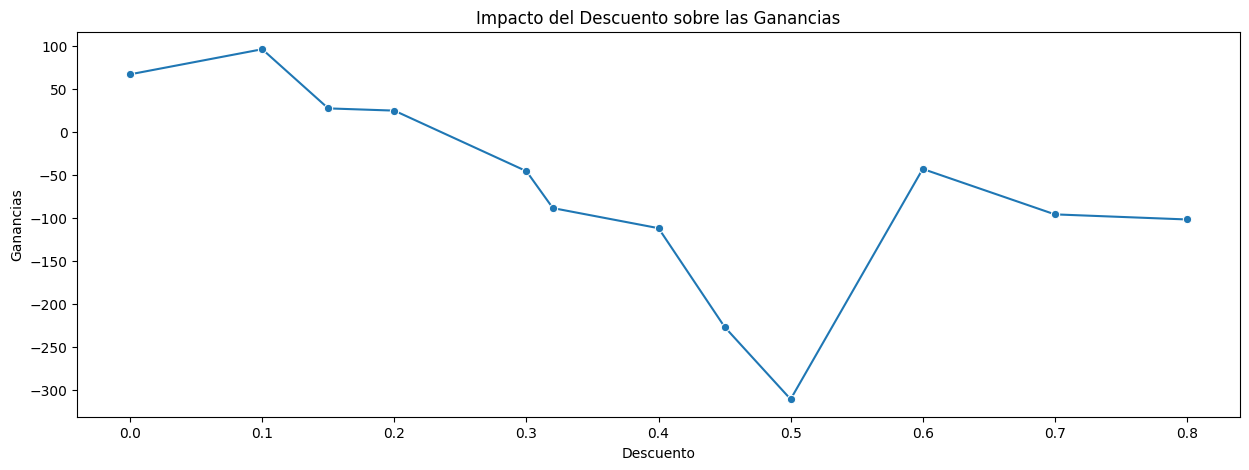

In [13]:
descuento = data.groupby('Discount')['Profit'].mean()
plt.figure(figsize=(15,5))
sbn.lineplot(x=descuento.index, y=descuento.values, marker='o')
plt.title('Impacto del Descuento sobre las Ganancias')
plt.xlabel('Descuento')
plt.ylabel('Ganancias')
plt.show()

# 5. ¿Qué segmento de clientes genera más ingresos y cuál más ganancias?

In [14]:
# ¿Qué segmento de clientes genera más ingresos y cuál más ganancias?

clients = (data.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}))
clients

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


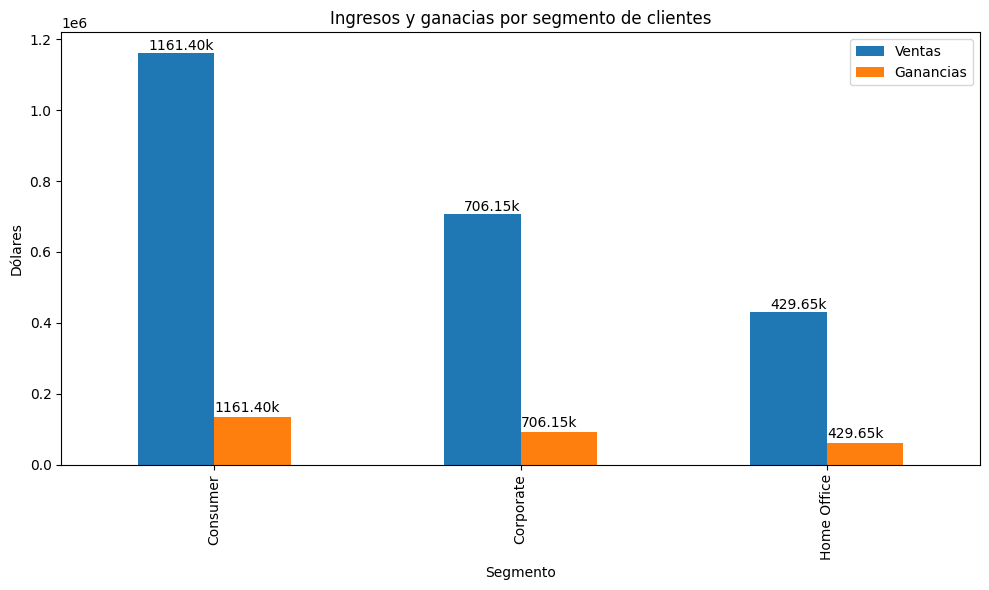

In [15]:
clients.plot(kind='bar', figsize=(10,6))
plt.title('Ingresos y ganacias por segmento de clientes')
plt.xlabel('Segmento')
plt.ylabel('Dólares')
plt.legend(['Ventas', 'Ganancias'])
for i, (ventas, ganancias) in enumerate(zip(clients['Sales'], clients['Profit'])):
  plt.text(i, ventas + 1000, f'{ventas/1e3:.2f}k', ha='right', va='bottom')
  plt.text(i, ganancias + 5000, f'{ventas/1e3:.2f}k', ha='left', va='bottom')
plt.tight_layout()
plt.show()

# 6. ¿Quiénes son los clientes más valiosos (mayor gasto total)?

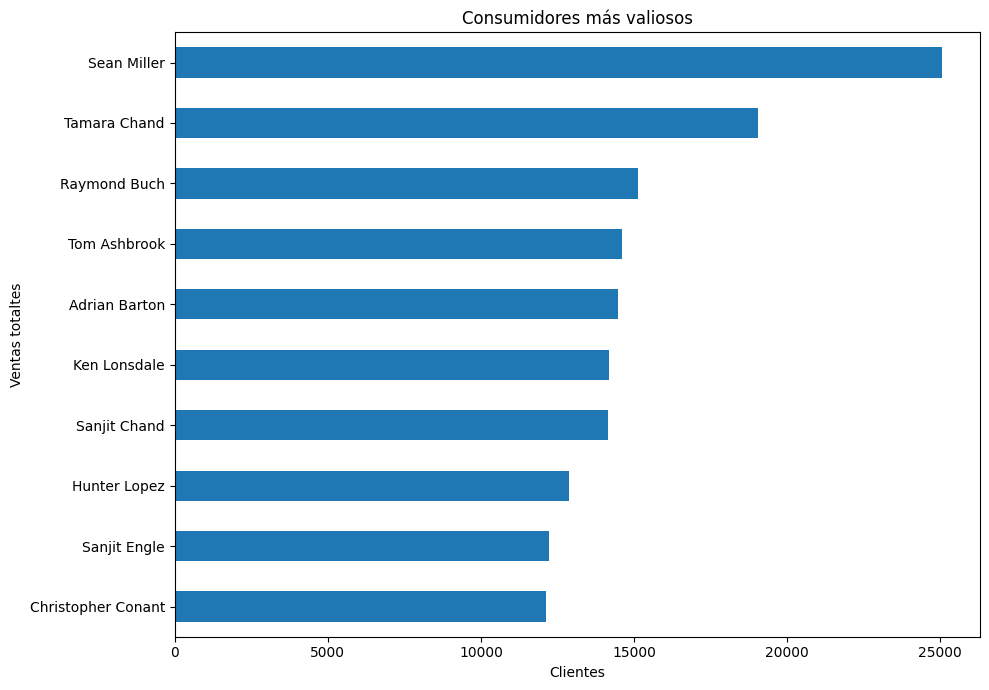

In [16]:
# ¿Quiénes son los clientes más valiosos (mayor gasto total)?
top_consumidores = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,7))
top_consumidores.plot(kind='barh')
plt.title('Consumidores más valiosos')
plt.ylabel('Ventas totaltes')
plt.xlabel('Clientes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 7. ¿Cuántos clientes únicos hay por región o segmento?


In [17]:
# ¿Cuántos clientes únicos hay por región o segmento?

clientes_seg = data.groupby('Segment')['Customer ID'].nunique()
clientes_seg

,Customer ID
Segment,
Consumer,409
Corporate,236
Home Office,148


In [18]:
clientes_reg = data.groupby('Region')['Customer ID'].nunique().sort_values(ascending=False)
clientes_reg

,Customer ID
Region,
West,686
East,674
Central,629
South,512


# 8. Tiempo promedio entre pedido y envío

In [19]:
# Tiempo promedio entre pedido y envío

data['Tiempo de envio'] = (data['Ship Date'] - data['Order Date']).dt.days
print(f'El tiempo promedio de envio entre pedidos es de: {data['Tiempo de envio'].mean():.2f} días')

El tiempo promedio de envio entre pedidos es de: 3.96 días


# 9. Método de envío más usado y más rentable

In [26]:
# Método de envío más usado y más rentable

ship_metodo = data['Ship Mode'].value_counts()
ship_metodo

,count
Ship Mode,
Standard Class,5968
Second Class,1945
First Class,1538
Same Day,543


In [38]:
data.groupby('Ship Mode')['Profit'].mean().round(2).sort_values(ascending=False)

,Profit
Ship Mode,
First Class,31.84
Second Class,29.54
Same Day,29.27
Standard Class,27.49


# 10. Total de ventas por mes

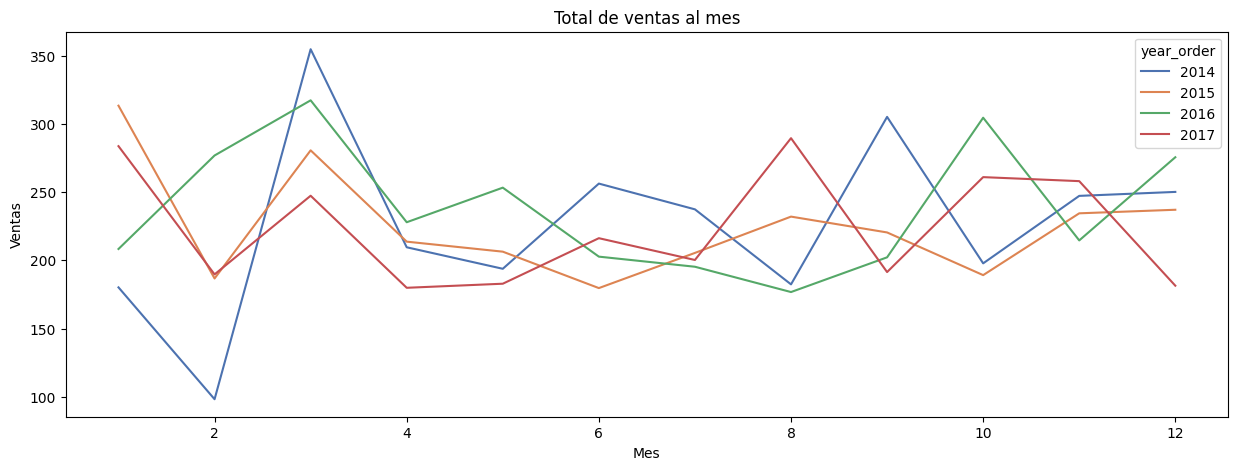

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

# Total de ventas por mes

data['year_order'] = data['Order Date'].dt.year
data['month_order'] = data['Order Date'].dt.month
plt.figure(figsize=(15,5))
sbn.lineplot(x='month_order', y='Sales', hue='year_order', data=data, palette='deep', errorbar=None)
plt.title('Total de ventas al mes')
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.show()

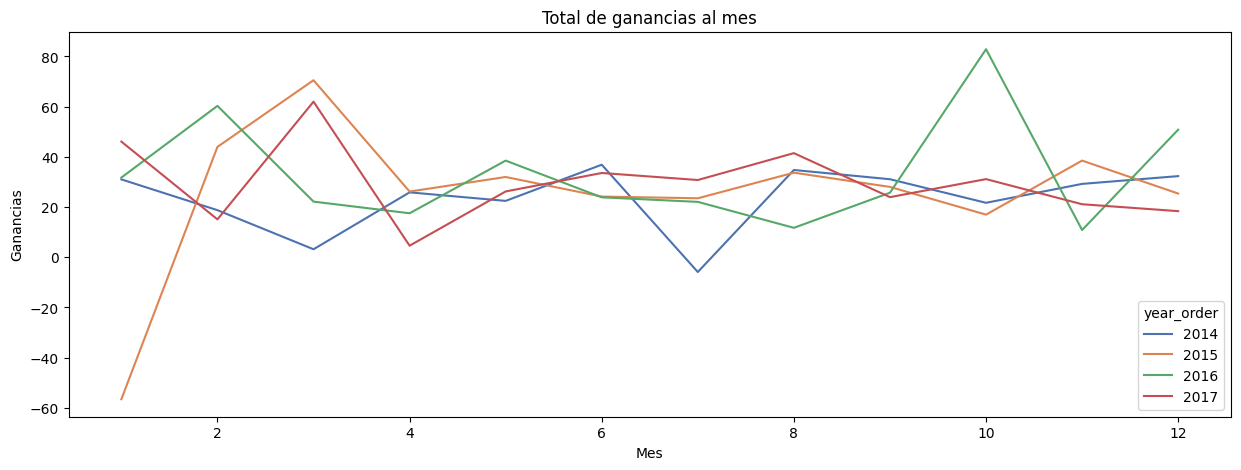

In [43]:
data['year_order'] = data['Order Date'].dt.year
data['month_order'] = data['Order Date'].dt.month
plt.figure(figsize=(15,5))
sbn.lineplot(x='month_order', y='Profit', hue='year_order', data=data, palette='deep', errorbar=None)
plt.title('Total de ganancias al mes')
plt.xlabel('Mes')
plt.ylabel('Ganancias')
plt.show()

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           9994 non-null   int64         
 1   Order ID         9994 non-null   object        
 2   Order Date       9994 non-null   datetime64[ns]
 3   Ship Date        9994 non-null   datetime64[ns]
 4   Ship Mode        9994 non-null   object        
 5   Customer ID      9994 non-null   object        
 6   Customer Name    9994 non-null   object        
 7   Segment          9994 non-null   object        
 8   Country          9994 non-null   object        
 9   City             9994 non-null   object        
 10  State            9994 non-null   object        
 11  Postal Code      9994 non-null   int64         
 12  Region           9994 non-null   object        
 13  Product ID       9994 non-null   object        
 14  Category         9994 non-null   object 